In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("data//fraud_oracle.csv")

In [6]:
pd.set_option('display.max_columns',None)

In [7]:
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,Fault,PolicyType,VehicleCategory,VehiclePrice,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,21,Policy Holder,Sport - Liability,Sport,more than 69000,0,1,12,300,1,more than 30,more than 30,none,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,34,Policy Holder,Sport - Collision,Sport,more than 69000,0,2,15,400,4,more than 30,more than 30,none,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,47,Policy Holder,Sport - Collision,Sport,more than 69000,0,3,7,400,3,more than 30,more than 30,1,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,65,Third Party,Sedan - Liability,Sport,20000 to 29000,0,4,4,400,2,more than 30,more than 30,1,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,27,Third Party,Sport - Collision,Sport,more than 69000,0,5,3,400,1,more than 30,more than 30,none,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [8]:
df.shape

(15420, 33)

In [9]:
df.isnull().sum()

Month                   0
WeekOfMonth             0
DayOfWeek               0
Make                    0
AccidentArea            0
DayOfWeekClaimed        0
MonthClaimed            0
WeekOfMonthClaimed      0
Sex                     0
MaritalStatus           0
Age                     0
Fault                   0
PolicyType              0
VehicleCategory         0
VehiclePrice            0
FraudFound_P            0
PolicyNumber            0
RepNumber               0
Deductible              0
DriverRating            0
Days_Policy_Accident    0
Days_Policy_Claim       0
PastNumberOfClaims      0
AgeOfVehicle            0
AgeOfPolicyHolder       0
PoliceReportFiled       0
WitnessPresent          0
AgentType               0
NumberOfSuppliments     0
AddressChange_Claim     0
NumberOfCars            0
Year                    0
BasePolicy              0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.nunique()

Month                      12
WeekOfMonth                 5
DayOfWeek                   7
Make                       19
AccidentArea                2
DayOfWeekClaimed            8
MonthClaimed               13
WeekOfMonthClaimed          5
Sex                         2
MaritalStatus               4
Age                        66
Fault                       2
PolicyType                  9
VehicleCategory             3
VehiclePrice                6
FraudFound_P                2
PolicyNumber            15420
RepNumber                  16
Deductible                  4
DriverRating                4
Days_Policy_Accident        5
Days_Policy_Claim           4
PastNumberOfClaims          4
AgeOfVehicle                8
AgeOfPolicyHolder           9
PoliceReportFiled           2
WitnessPresent              2
AgentType                   2
NumberOfSuppliments         4
AddressChange_Claim         5
NumberOfCars                5
Year                        3
BasePolicy                  3
dtype: int

In [12]:
df.drop(columns=['PolicyNumber'],inplace=True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  FraudFound_P          15420 non-null

In [14]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Month,15420,12,Jan,1411,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WeekOfMonth,15420.0,NaN,NaN,NaN,2.788586,1.287585,1.0,2.0,3.0,4.0,5.0
DayOfWeek,15420,7,Monday,2616,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Make,15420,19,Pontiac,3837,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AccidentArea,15420,2,Urban,13822,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DayOfWeekClaimed,15420,8,Monday,3757,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MonthClaimed,15420,13,Jan,1446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WeekOfMonthClaimed,15420.0,NaN,NaN,NaN,2.693969,1.259115,1.0,2.0,3.0,4.0,5.0
Sex,15420,2,Male,13000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MaritalStatus,15420,4,Married,10625,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

numerical_columns

['WeekOfMonth',
 'WeekOfMonthClaimed',
 'Age',
 'FraudFound_P',
 'RepNumber',
 'Deductible',
 'DriverRating',
 'Year']

In [16]:
categorical_columns = df.select_dtypes(
    include=["object"]
).columns.tolist()
categorical_columns

['Month',
 'DayOfWeek',
 'Make',
 'AccidentArea',
 'DayOfWeekClaimed',
 'MonthClaimed',
 'Sex',
 'MaritalStatus',
 'Fault',
 'PolicyType',
 'VehicleCategory',
 'VehiclePrice',
 'Days_Policy_Accident',
 'Days_Policy_Claim',
 'PastNumberOfClaims',
 'AgeOfVehicle',
 'AgeOfPolicyHolder',
 'PoliceReportFiled',
 'WitnessPresent',
 'AgentType',
 'NumberOfSuppliments',
 'AddressChange_Claim',
 'NumberOfCars',
 'BasePolicy']

In [17]:
target_counts = df["FraudFound_P"].value_counts()
target_counts

FraudFound_P
0    14497
1      923
Name: count, dtype: int64

<Axes: xlabel='FraudFound_P', ylabel='count'>

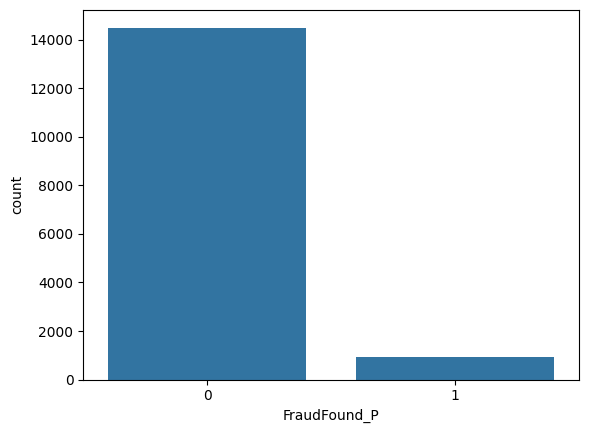

In [18]:
sns.countplot(
    data=df,
    x="FraudFound_P"
)

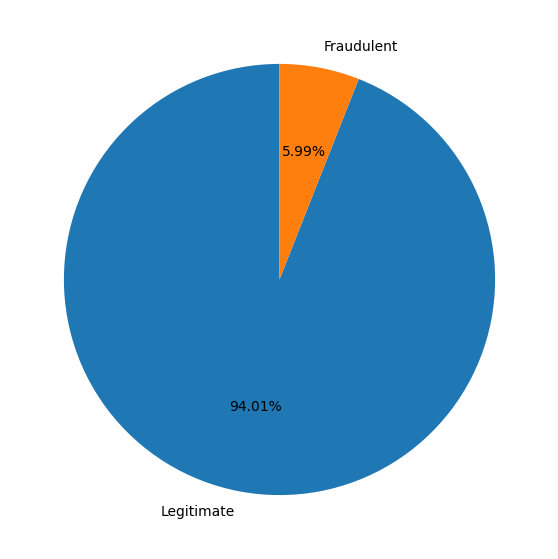

In [19]:
counts = df["FraudFound_P"].value_counts()

labels = ["Legitimate", "Fraudulent"]

plt.figure(figsize=(7, 7))

plt.pie(
    counts,
    labels=labels,
    autopct="%1.2f%%",
    startangle=90
)
plt.show()

In [20]:
def fraud_rate_table(data, column, min_count=0):
    
    result = (
        data.groupby(column)["FraudFound_P"]
        .agg(
            Claims="count",
            Fraudulent="sum",
            Fraud_Rate="mean"
        )
        .reset_index()
    )
    
    result["Fraud_Rate"] = (
        result["Fraud_Rate"] * 100
    ).round(2)
    
    if min_count > 0:
        result = result[result["Claims"] >= min_count]
    
    return result.sort_values(
        "Fraud_Rate",
        ascending=False
    )

for i in df.columns:
    print(fraud_rate_table(df, i))

   Month  Claims  Fraudulent  Fraud_Rate
7    Mar    1360         102        7.50
1    Aug    1127          84        7.45
8    May    1367          94        6.88
3    Feb    1266          82        6.48
0    Apr    1280          80        6.25
4    Jan    1411          87        6.17
11   Sep    1240          76        6.13
6    Jun    1321          80        6.06
10   Oct    1305          70        5.36
2    Dec    1285          62        4.82
5    Jul    1257          60        4.77
9    Nov    1201          46        3.83
   WeekOfMonth  Claims  Fraudulent  Fraud_Rate
1            2    3558         225        6.32
0            1    3187         200        6.28
2            3    3640         215        5.91
3            4    3398         192        5.65
4            5    1637          91        5.56
   DayOfWeek  Claims  Fraudulent  Fraud_Rate
3     Sunday    1745         122        6.99
2   Saturday    1982         132        6.66
0     Friday    2445         154        6.30
1    

In [21]:
#cleraly Week of month ,day of week, WeekOfMonthClaimed ,dirver rating,year  is not play big role reason all are the same fraud rate almost
df.drop(columns=["WeekOfMonth","DayOfWeek","WeekOfMonthClaimed","DayOfWeekClaimed","DriverRating","Year"],inplace=True)

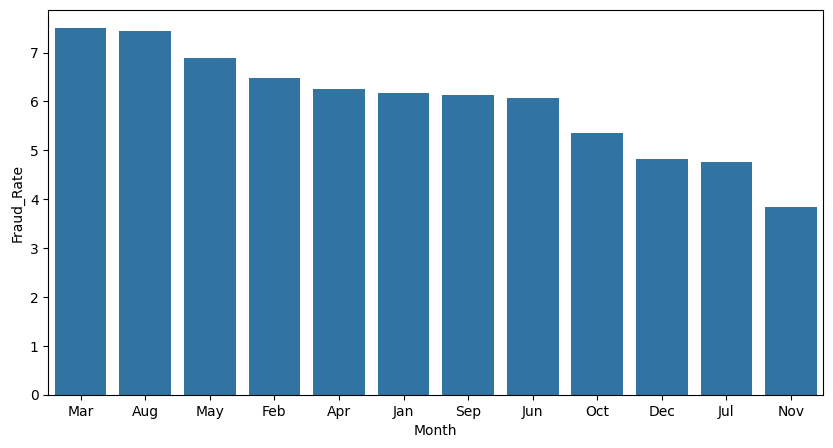

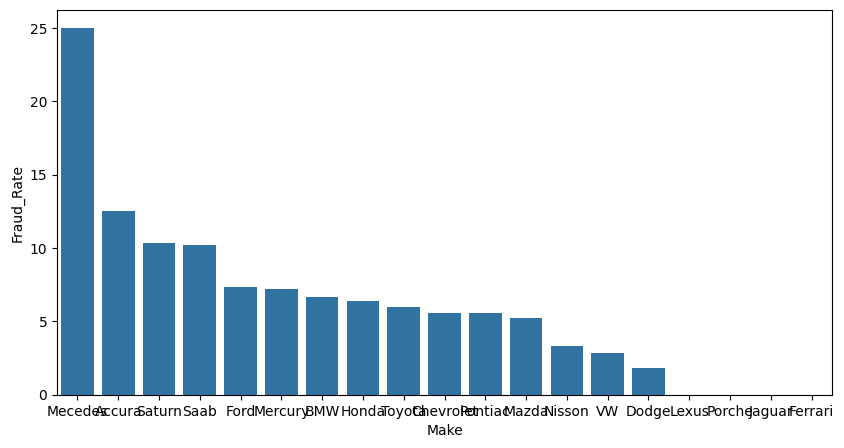

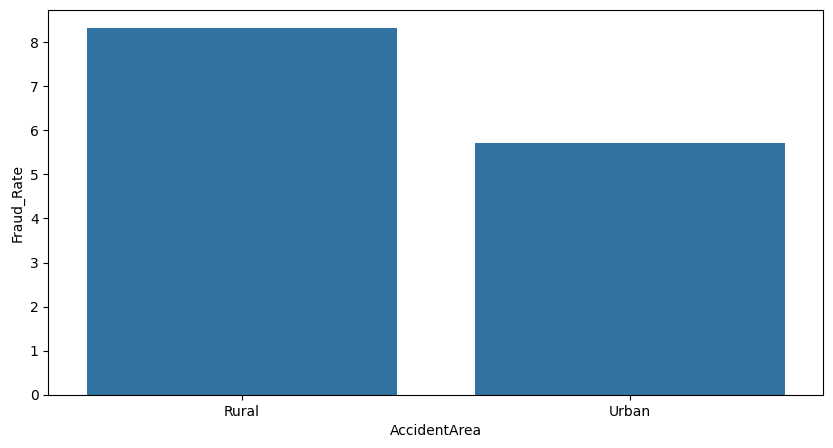

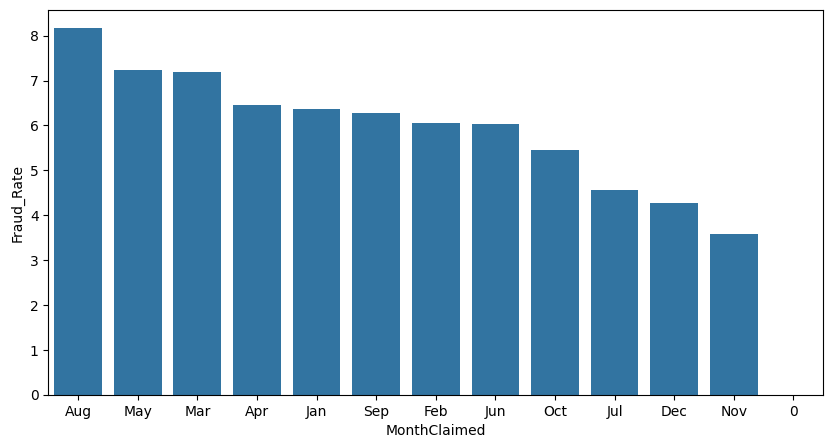

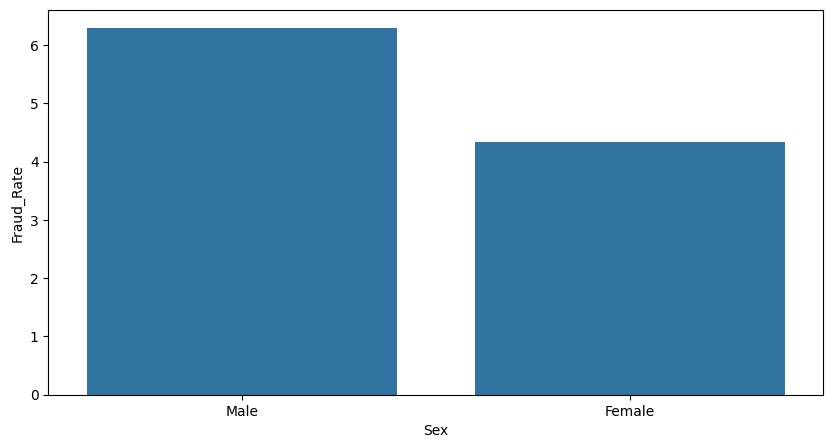

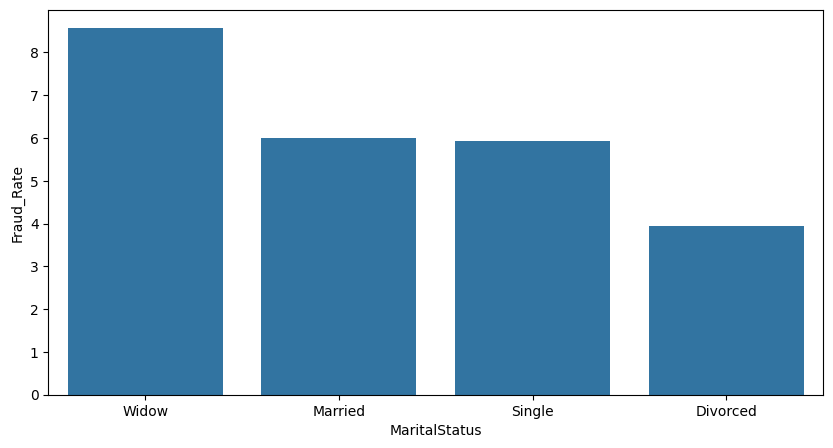

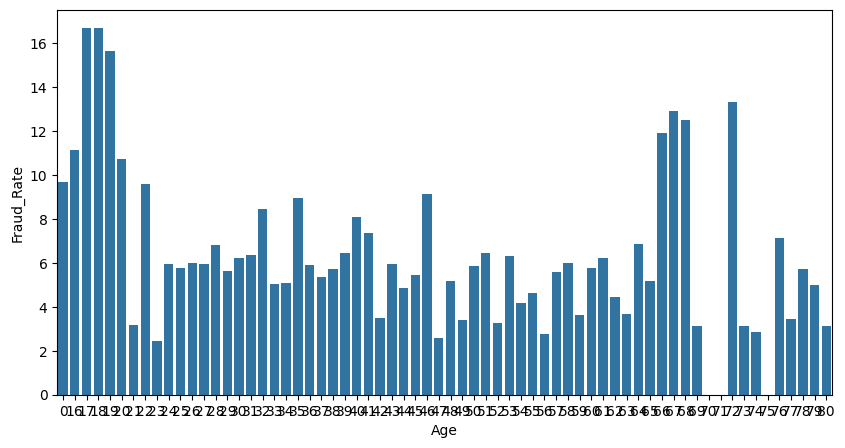

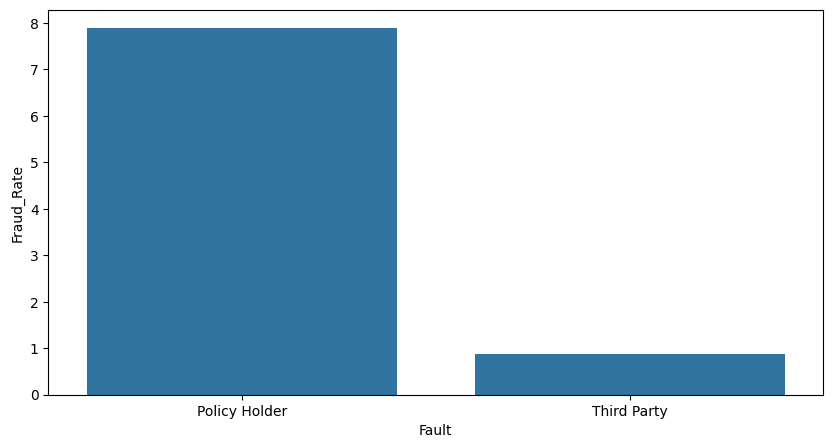

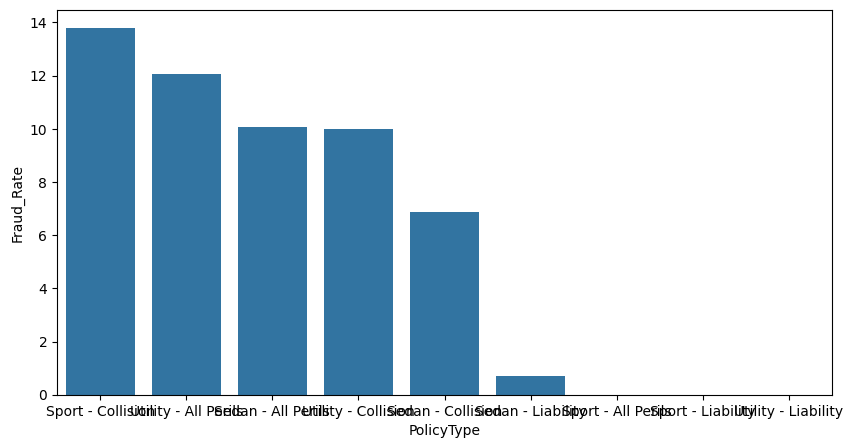

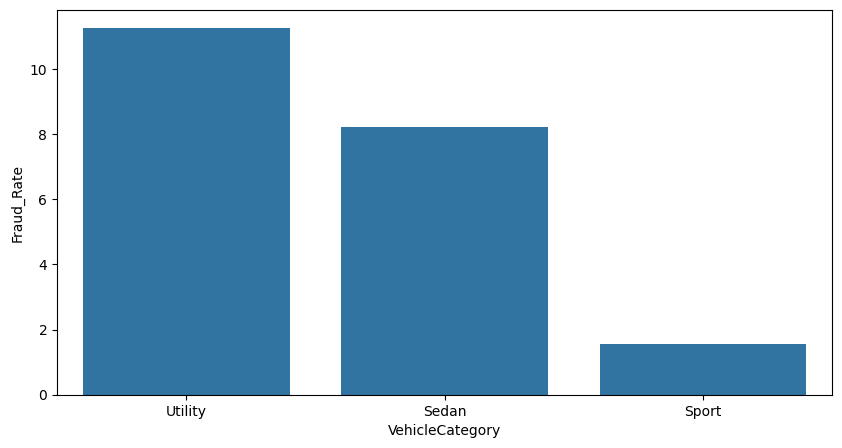

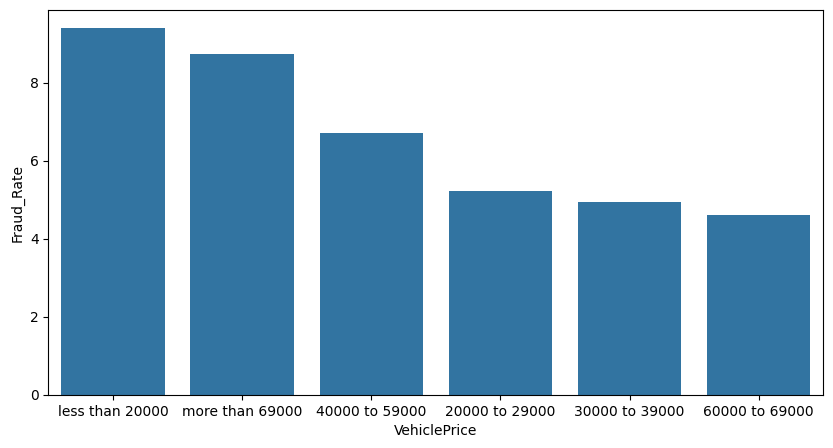

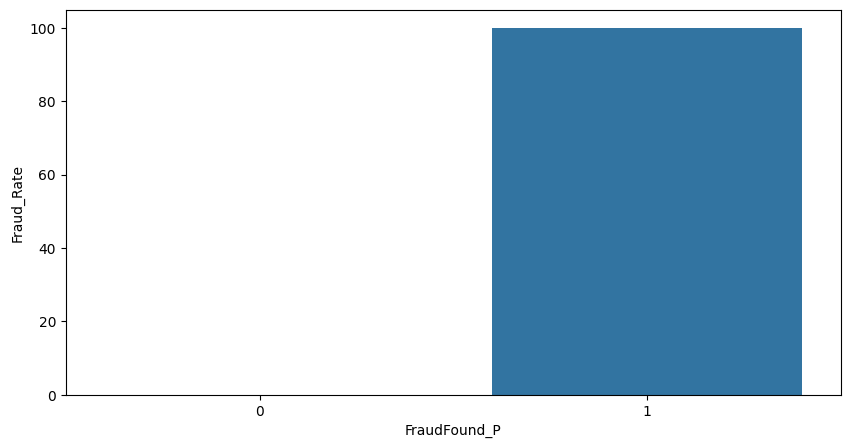

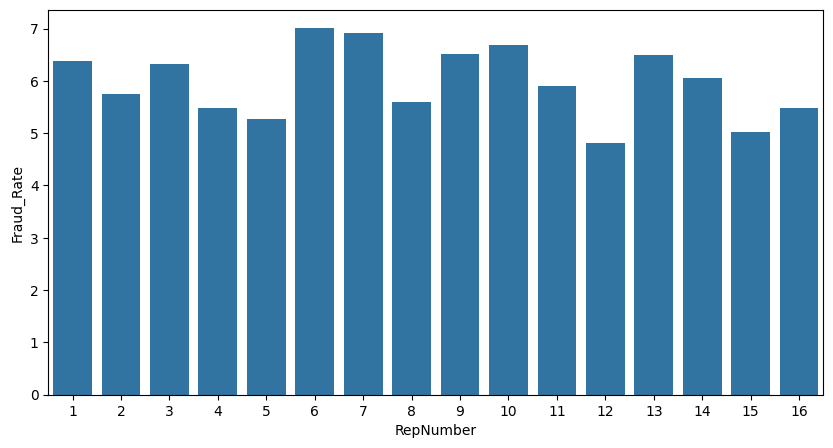

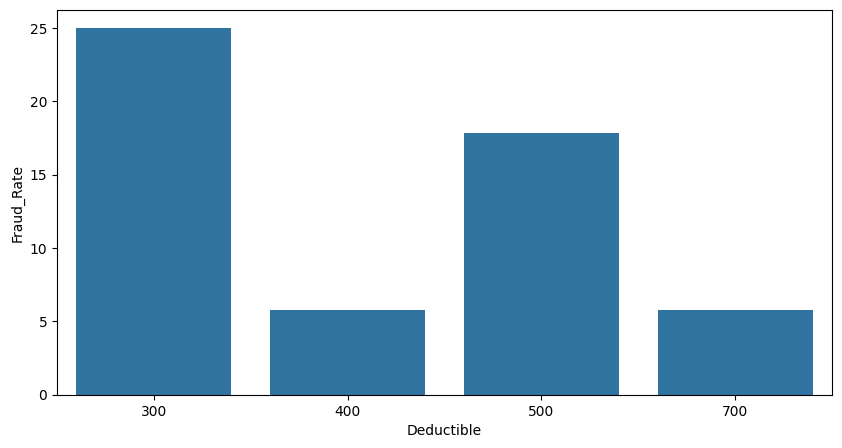

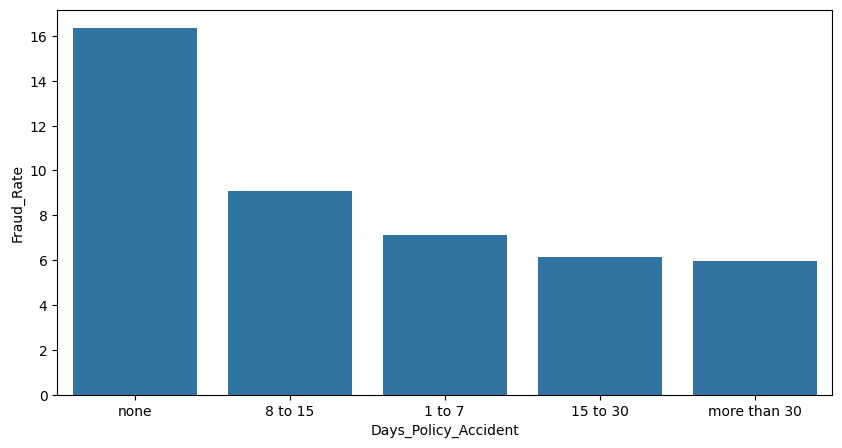

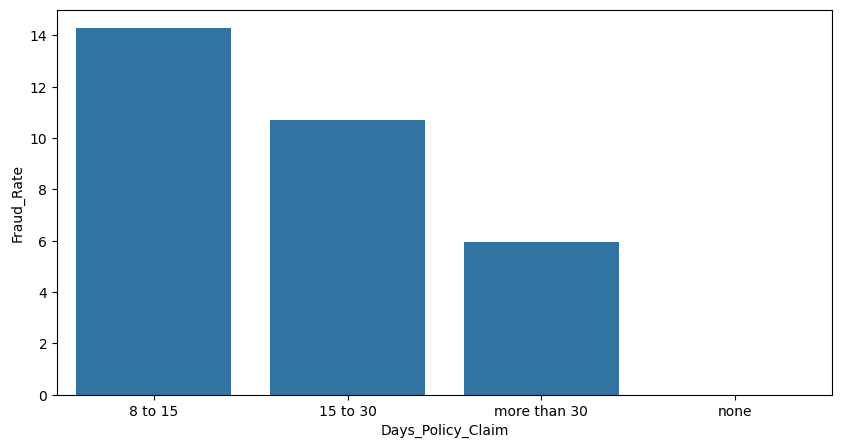

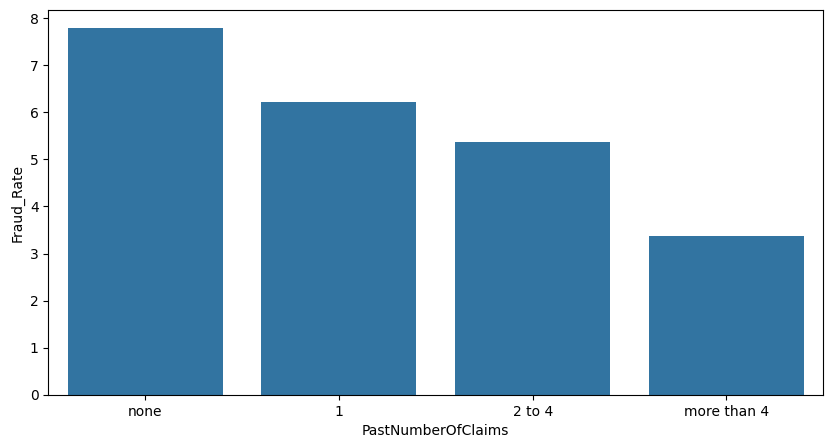

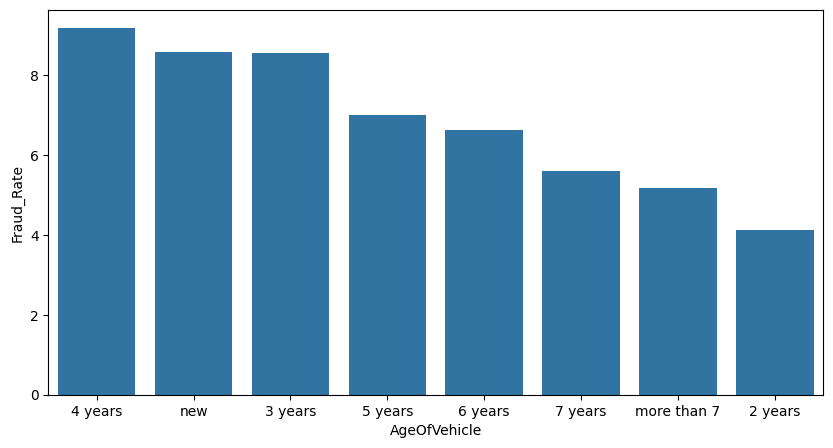

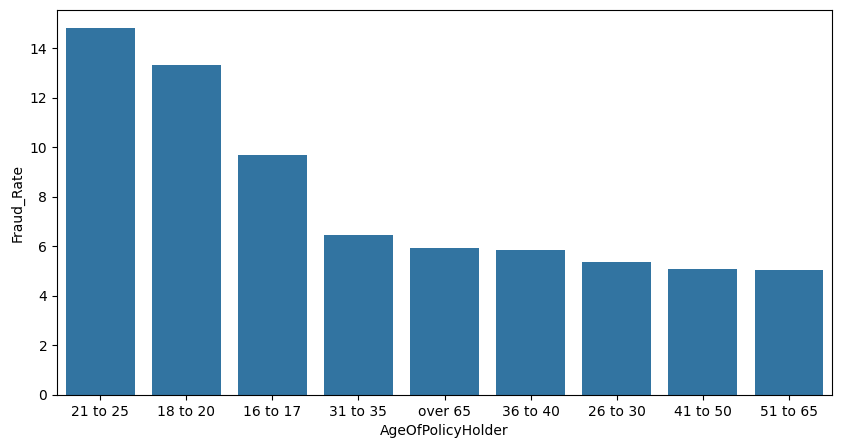

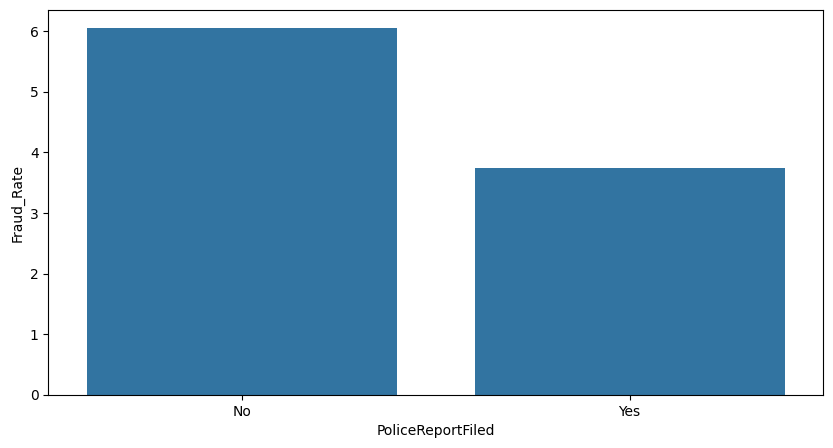

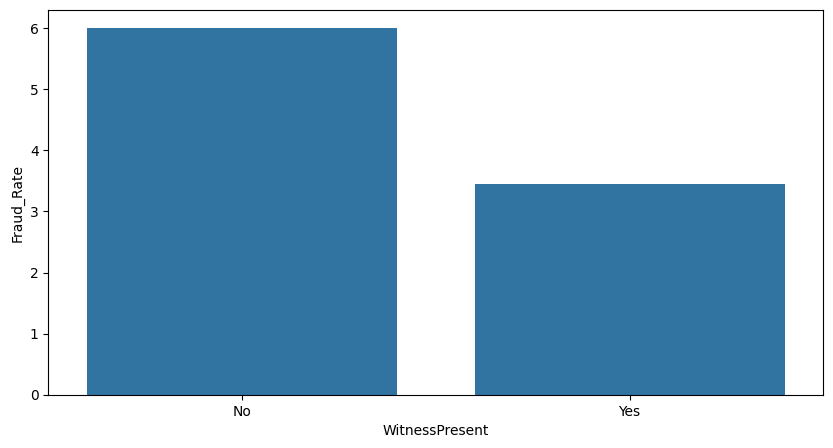

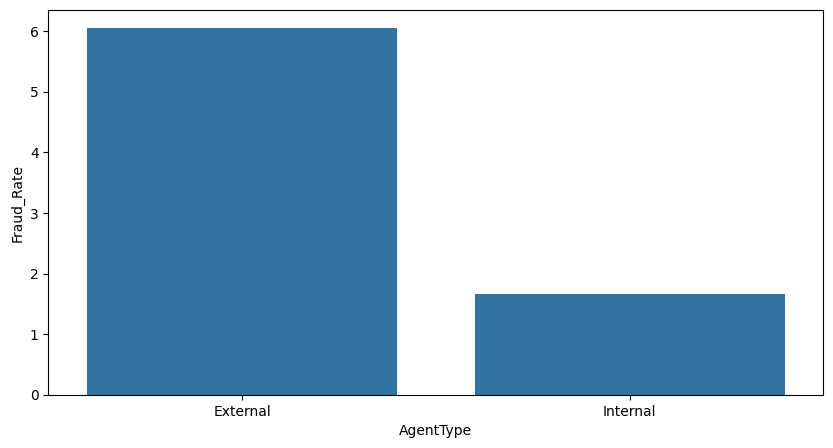

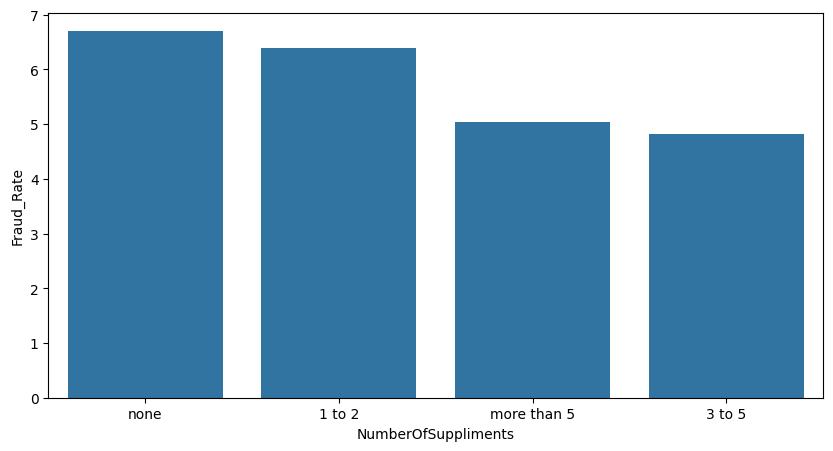

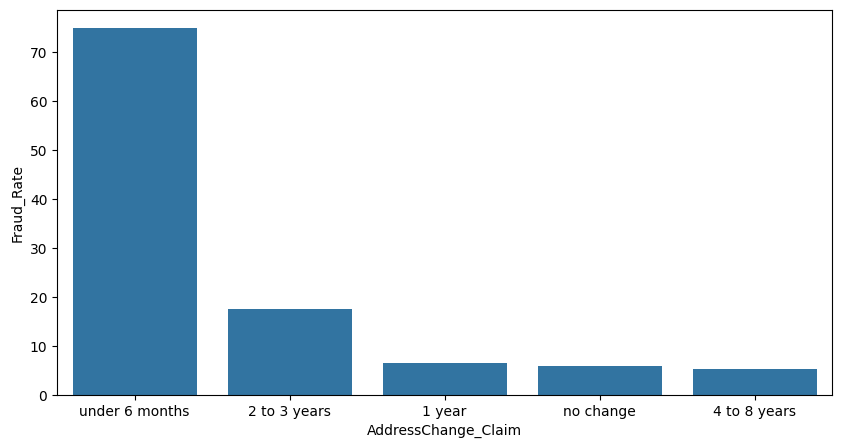

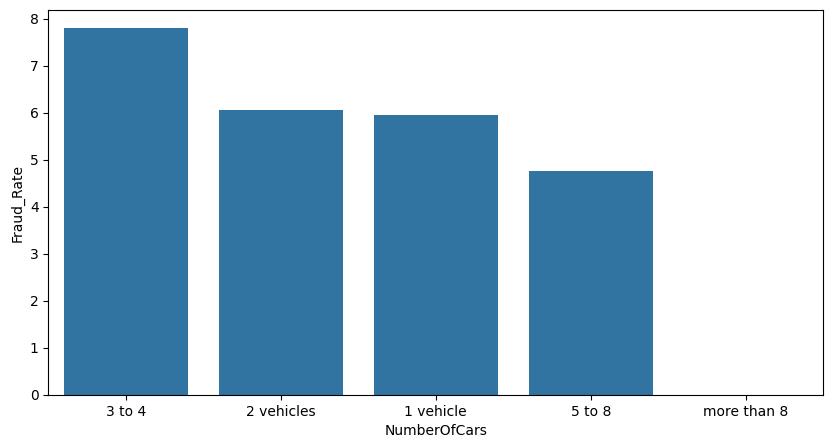

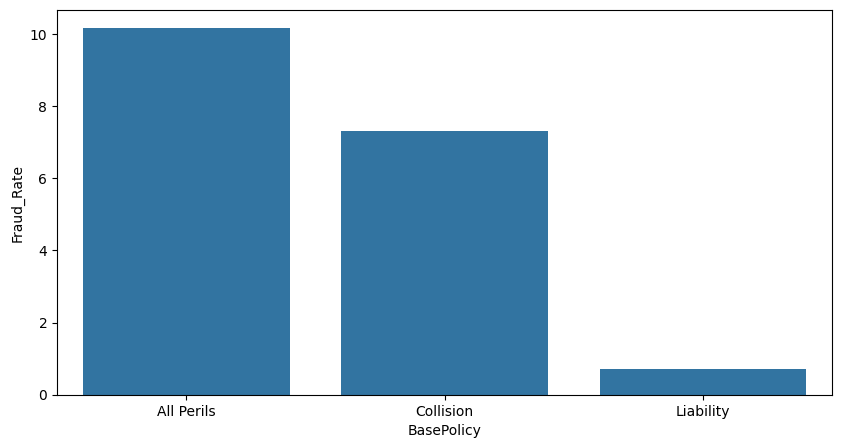

In [22]:
for i in df.columns:
    table = fraud_rate_table(df, i)
    plt.figure(figsize=(10, 5))
    sns.barplot(data=table,x=i,y="Fraud_Rate")
    
    plt.show()


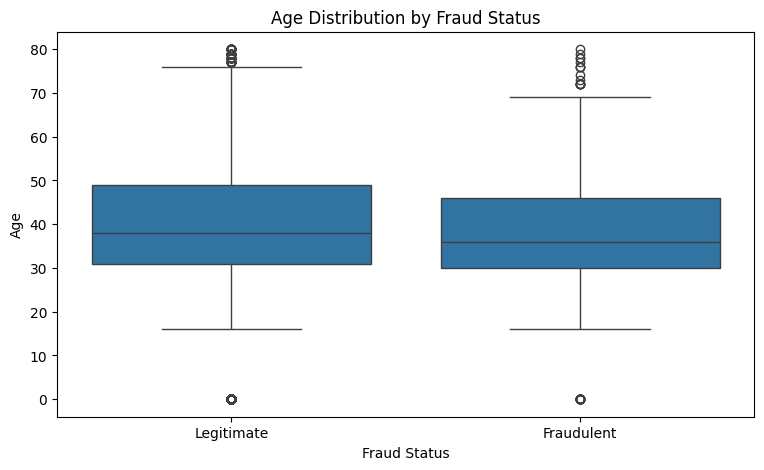

In [23]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="FraudFound_P",
    y="Age"
)

plt.title("Age Distribution by Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("Age")

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraudulent"]
)

plt.show()

In [24]:

#after deletion of not helpful features
categorical_columns = df.select_dtypes(
    include=["object"]
).columns.tolist()
categorical_columns

['Month',
 'Make',
 'AccidentArea',
 'MonthClaimed',
 'Sex',
 'MaritalStatus',
 'Fault',
 'PolicyType',
 'VehicleCategory',
 'VehiclePrice',
 'Days_Policy_Accident',
 'Days_Policy_Claim',
 'PastNumberOfClaims',
 'AgeOfVehicle',
 'AgeOfPolicyHolder',
 'PoliceReportFiled',
 'WitnessPresent',
 'AgentType',
 'NumberOfSuppliments',
 'AddressChange_Claim',
 'NumberOfCars',
 'BasePolicy']

In [25]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

numerical_columns

['Age', 'FraudFound_P', 'RepNumber', 'Deductible']

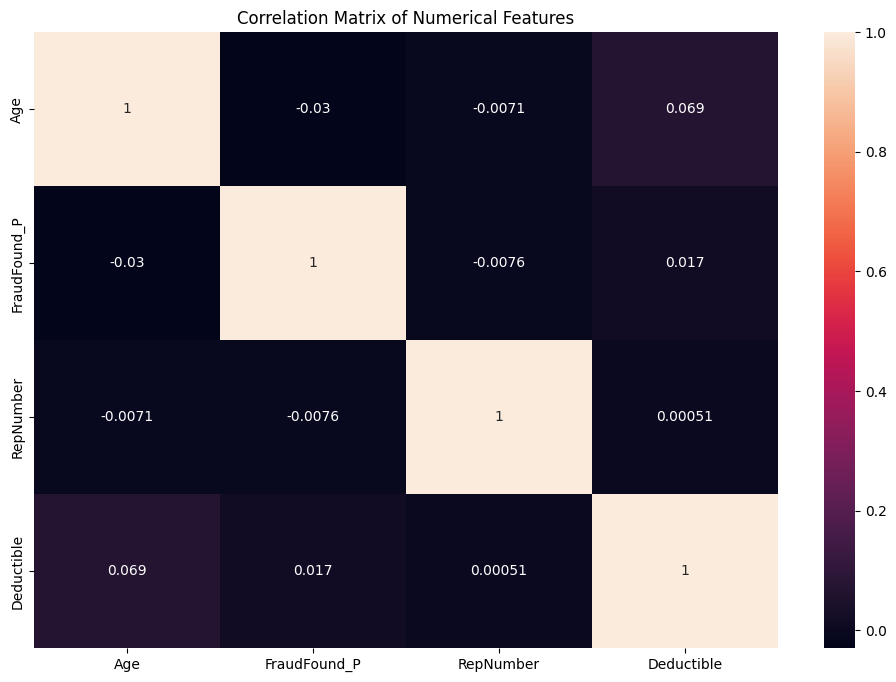

In [26]:
corr = df[numerical_columns].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

In [27]:
df.nunique()

Month                   12
Make                    19
AccidentArea             2
MonthClaimed            13
Sex                      2
MaritalStatus            4
Age                     66
Fault                    2
PolicyType               9
VehicleCategory          3
VehiclePrice             6
FraudFound_P             2
RepNumber               16
Deductible               4
Days_Policy_Accident     5
Days_Policy_Claim        4
PastNumberOfClaims       4
AgeOfVehicle             8
AgeOfPolicyHolder        9
PoliceReportFiled        2
WitnessPresent           2
AgentType                2
NumberOfSuppliments      4
AddressChange_Claim      5
NumberOfCars             5
BasePolicy               3
dtype: int64

In [28]:
df.duplicated().sum()

15

In [29]:
df.drop_duplicates(inplace=True)

In [30]:
df.columns

Index(['Month', 'Make', 'AccidentArea', 'MonthClaimed', 'Sex', 'MaritalStatus',
       'Age', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice',
       'FraudFound_P', 'RepNumber', 'Deductible', 'Days_Policy_Accident',
       'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle',
       'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars',
       'BasePolicy'],
      dtype='object')

In [31]:
numerical_columns.remove('FraudFound_P')

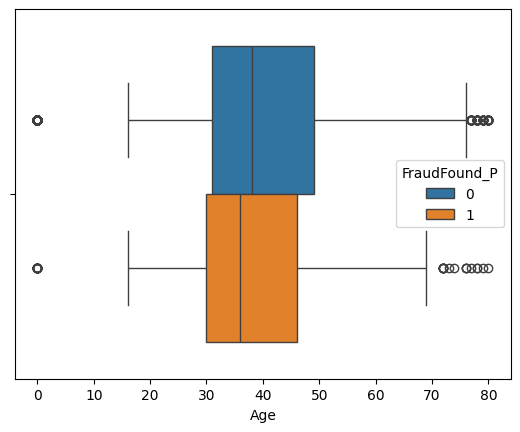

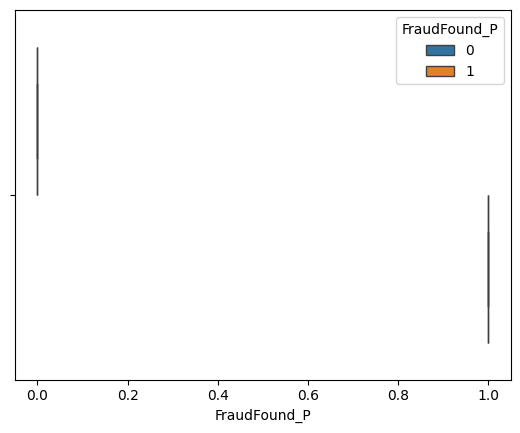

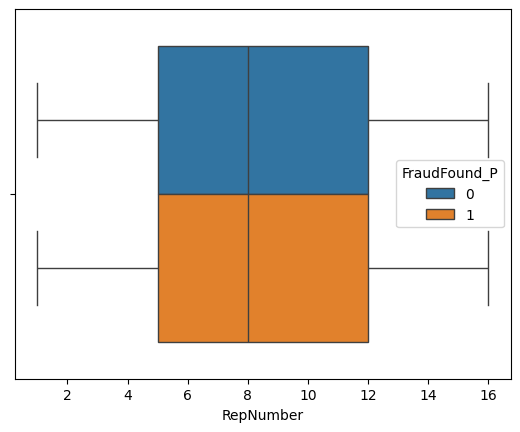

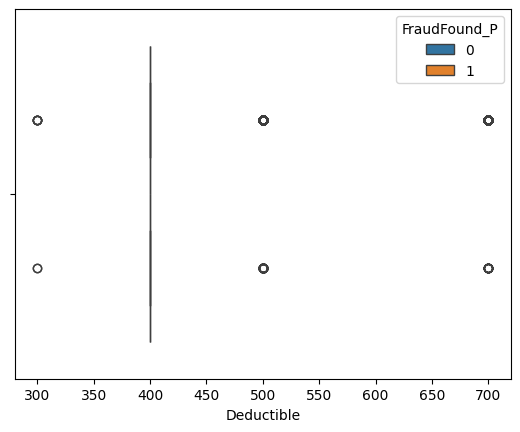

In [32]:
for col in df.columns:
    if col not in categorical_columns:
        sns.boxplot(data=df,x=col,hue='FraudFound_P')
        plt.show()

In [33]:
X = df.drop(columns=["FraudFound_P"])

y = df["FraudFound_P"]

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [36]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

In [37]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

In [38]:
from sklearn.linear_model import LogisticRegression

lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

In [39]:
lr_model.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [40]:
y_pred = lr_model.predict(X_test)

In [41]:
from sklearn.metrics import  *

In [42]:
accuracy_score(y_test, y_pred)

0.6458941901979877

In [43]:
precision_score(y_test, y_pred)

0.13515687851971037

In [44]:
recall_score(y_test, y_pred)

0.9130434782608695

In [45]:
f1_score(y_test, y_pred)

0.23545900490539592

In [46]:
confusion_matrix(
    y_test,
    y_pred
)

array([[1822, 1075],
       [  16,  168]], dtype=int64)

In [59]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [60]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state = 42),
    'Random forest': RandomForestClassifier(random_state = 42),
    'XGBoost': XGBClassifier(random_state = 42)
}

In [64]:
from sklearn.model_selection import cross_validate


scoring_metrics = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']

cv_results = {}

for model_name, model in models.items():
    print(f'{model_name} is running...')
    
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    scores = cross_validate(
        pipeline, 
        X_train, 
        y_train, 
        cv=5, 
        scoring=scoring_metrics,
        return_train_score=False
    )
    
    cv_results[model_name] = scores
    
    # Print the mean scores
    print(f"{model_name} Results:")
    print(f"  Accuracy:  {np.mean(scores['test_accuracy']):.4f}")
    print(f"  Precision: {np.mean(scores['test_precision_weighted']):.4f}")
    print(f"  Recall:    {np.mean(scores['test_recall_weighted']):.4f}")
    print(f"  F1-Score:  {np.mean(scores['test_f1_weighted']):.4f}")
    print('-' * 50)


Decision Tree is running...
Decision Tree Results:
  Accuracy:  0.8919
  Precision: 0.9013
  Recall:    0.8919
  F1-Score:  0.8965
--------------------------------------------------
Random forest is running...
Random forest Results:
  Accuracy:  0.9405
  Precision: 0.9216
  Recall:    0.9405
  F1-Score:  0.9144
--------------------------------------------------
XGBoost is running...
XGBoost Results:
  Accuracy:  0.9381
  Precision: 0.9104
  Recall:    0.9381
  F1-Score:  0.9165
--------------------------------------------------
